# TASK 1 : Problem Identification

This dataset is an Image Classification problem because each image is assigned one defect category label. The model learns to classify the entire image into one of four classes rather than locating or segmenting defects.

# Task 2: Dataset Exploration

Now, let's explore the dataset to understand its characteristics. This involves:
*   Number of classes
*   Number of images per class
*   Sample images from each class
*   Image dimensions
*   Any imbalance in the dataset



### Classes and Image per class

In [2]:
import os

dataset_path = "/content/drive/MyDrive/Colab Notebooks/part_2_cnn_computer_vision/images"

classes = os.listdir(dataset_path)

for cls in classes:
    path = os.path.join(dataset_path, cls)
    print(f"{cls}: {len(os.listdir(path))} images")

dent: 120 images
stain: 120 images
scratch: 120 images
normal: 120 images


### Sample Image Each Class


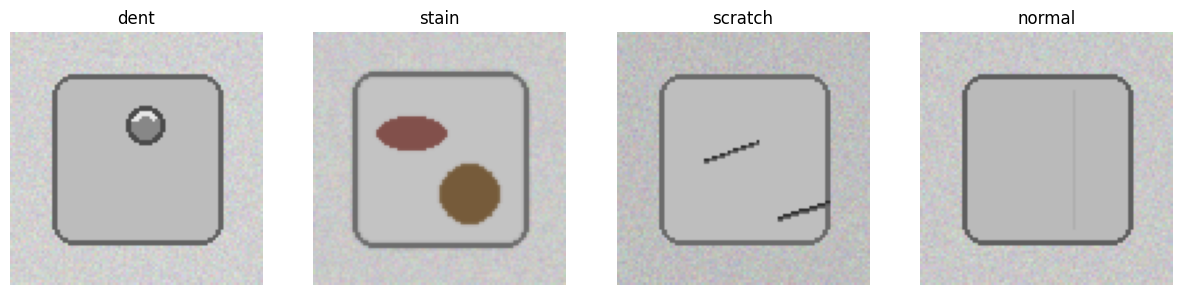

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 4, figsize=(15,5))

for i, cls in enumerate(classes):
    img_name = os.listdir(os.path.join(dataset_path, cls))[0]
    img_path = os.path.join(dataset_path, cls, img_name)

    img = Image.open(img_path)

    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.show()

### Image Dimention

In [6]:
from PIL import Image

for cls in classes:
    img_name = os.listdir(os.path.join(dataset_path, cls))[0]
    img_path = os.path.join(dataset_path, cls, img_name)

    img = Image.open(img_path)

    print(cls, img.size)

dent (96, 96)
stain (96, 96)
scratch (96, 96)
normal (96, 96)


###Any imbalance in the dataset ?

The dataset appears balanced because each class contains approximately equal numbers of images. Balanced datasets help CNN models learn equally across classes and reduce prediction bias.

#Task 3 — Image Preprocessing

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [8]:
# Image Parameters

IMG_SIZE = 128
BATCH_SIZE = 32

In [9]:
#Data Augmentation & Normalization

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)


In [12]:
# Training Data Set

train_data = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/Colab Notebooks/part_2_cnn_computer_vision/images",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 384 images belonging to 4 classes.


In [13]:
# Validation Dataset

val_data = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/Colab Notebooks/part_2_cnn_computer_vision/images",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 96 images belonging to 4 classes.


# Task 4: CNN Model Creation


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential()

# Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(128,128,3)))

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second CNN Block
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Third CNN Block
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(4, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Compile Model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Task 5 — Model Training and Evaluation

In [16]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 177s 15s/step - accuracy: 0.1953 - loss: 1.5496 - val_accuracy: 0.2500 - val_loss: 1.3809
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.2786 - loss: 1.3743 - val_accuracy: 0.3542 - val_loss: 1.3459
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.3698 - loss: 1.2779 - val_accuracy: 0.5521 - val_loss: 1.1502
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5234 - loss: 1.0646 - val_accuracy: 0.6667 - val_loss: 0.8899
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.6536 - loss: 0.8302 - val_accuracy: 0.7292 - val_loss: 0.7268
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.7500 - loss: 0.6337 - val_accuracy: 0.8333 - val_loss: 0.5113
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.7734 - loss: 0.6830 - val_accuracy: 0.9167 - val_loss: 0.4468
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.8047 - loss: 0.5117 - val_accuracy: 0.8542 - val_los

### Plot Accuracy & Loss

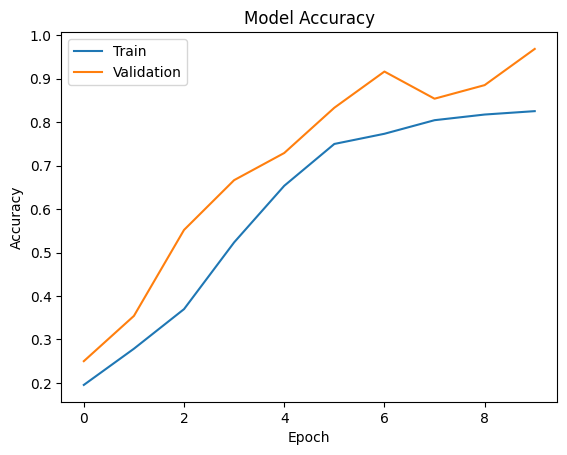

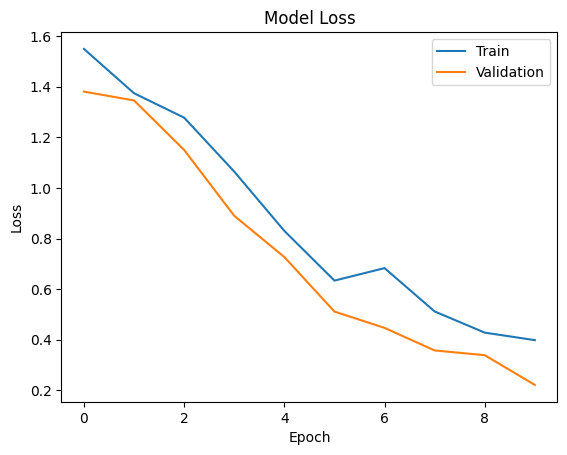

In [17]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train', 'Validation'])
plt.show()

### Testing Performance

In [18]:
loss, accuracy = model.evaluate(val_data)

print("Test Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 434ms/step - accuracy: 0.9375 - loss: 0.2366
Test Accuracy: 0.9375


### Confusion Matrix


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 350ms/step


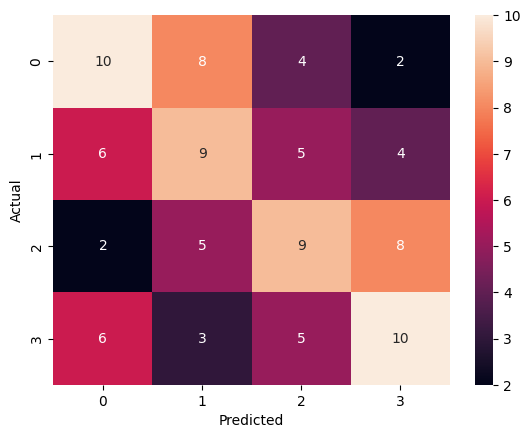

In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

predictions = model.predict(val_data)
y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(val_data.classes, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Sample Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 893ms/step


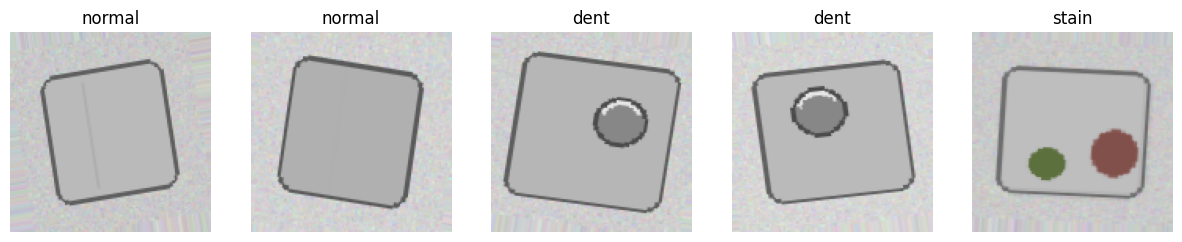

In [20]:
class_names = list(train_data.class_indices.keys())

images, labels = next(val_data)

preds = model.predict(images)

plt.figure(figsize=(15,10))

for i in range(5):
    plt.subplot(1,5,i+1)

    plt.imshow(images[i])

    pred_label = class_names[np.argmax(preds[i])]

    plt.title(pred_label)
    plt.axis("off")

plt.show()

# Task 6 : CNN Concept Explanation

## What is Convolution?

Convolution is an operation where small filters scan across an image to detect important visual features such as edges, textures, scratches, dents, and stains.

---

## Why is Pooling Used?

Pooling reduces the size of feature maps while keeping important information. It helps reduce computation and prevents overfitting.

---

## Why is ReLU Commonly Used in CNNs?

ReLU (Rectified Linear Unit) introduces non-linearity into the network and helps the model learn complex image patterns efficiently.

---

## Why are CNNs Better than Regular Feed-Forward Networks for Image Data?

CNNs are specifically designed for image processing. They automatically extract spatial features from images while using fewer parameters than traditional neural networks.


# Task 7 : Business Use Case Mapping

## Manufacturing Quality Inspection

Computer vision systems using CNNs can automatically inspect products for defects such as scratches, dents, and stains.

Benefits include:

- Faster inspection
- Reduced manual effort
- Improved quality control
- Lower manufacturing errors
- Increased production efficiency

This type of solution is commonly used in:
- Automotive manufacturing
- Electronics production
- Metal surface inspection
- Industrial automation